In [1]:

from transformers import GPT2Model, GPT2Tokenizer
import torch

# Load model and tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2", output_attentions=True)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [2]:
# Tokenize
# text = "The cat sat on the mat"
text = "The scientist studied the data carefully and discovered that the results contradicted her initial hypothesis about climate change."
words = text.split()
inputs = tokenizer(text, return_tensors="pt")

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)

# outputs.attentions: tuple of attention weights for each layer
# Shape: [batch, heads, seq_len, seq_len]
attn_weights = outputs.attentions[0][0]  # First layer, first batch
attn_weights.shape

torch.Size([12, 19, 19])

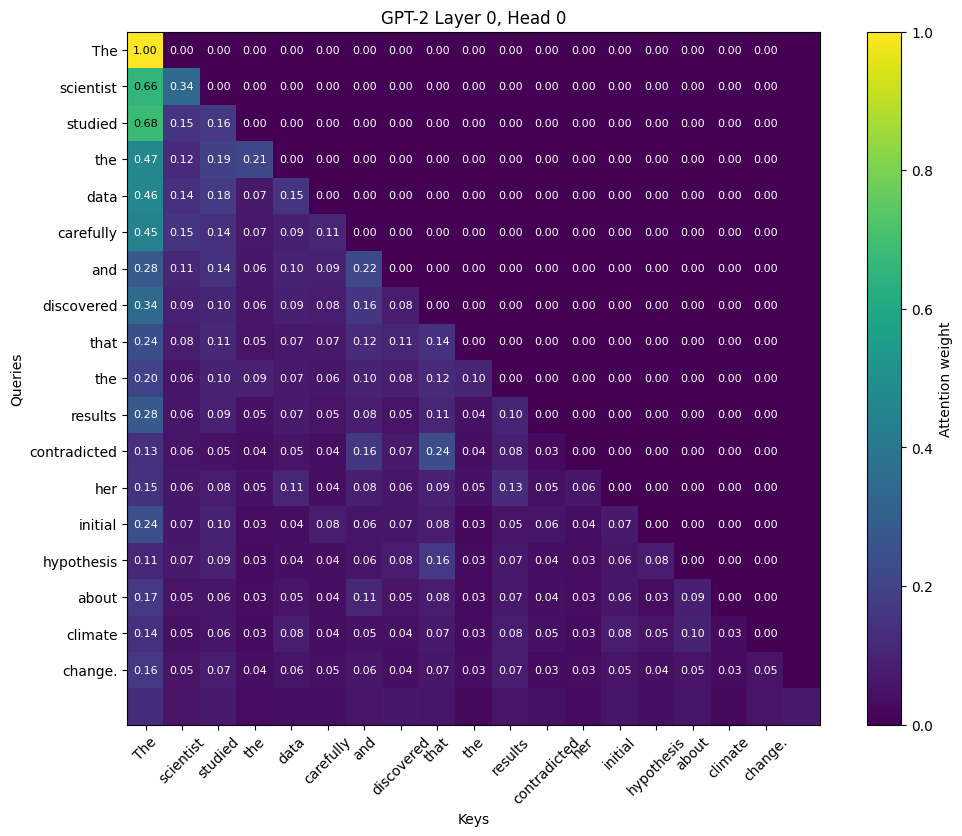

In [17]:
from matplotlib import pyplot as plt
# attn = attn_weights[11].detach().numpy()  # Layer 0, Head 0
attn = outputs.attentions[0][0, 11].detach().numpy()
plt.figure(figsize=(12, 9))
plt.imshow(attn, cmap='viridis')
plt.xticks(range(len(words)), words, rotation=45)
plt.yticks(range(len(words)), words)
# Add value annotations
for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f"{attn[i, j]:.2f}", ha="center", va="center", color="white" if attn[i, j] < 0.5 else "black", fontsize=8)
plt.colorbar(label='Attention weight')
plt.xlabel('Keys')
plt.ylabel('Queries')
plt.title('GPT-2 Layer 0, Head 0')
plt.show()

In [7]:
attn = outputs.attentions[11][0, 0].detach().numpy()
# Print markdown table header
header = "| | " + " | ".join(words) + " |"
print(header)
print("|" + "|".join(["---"] * (len(words) + 1)) + "|")
# Print each row
for i, word in enumerate(words):
    row = f"| **{word}** | " + " | ".join([f"{attn[i, j]:.3f}" for j in range(len(words))]) + " |"
    print(row)

| | The | scientist | studied | the | data | carefully | and | discovered | that | the | results | contradicted | her | initial | hypothesis | about | climate | change. |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| **The** | 1.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 |
| **scientist** | 0.436 | 0.564 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 |
| **studied** | 0.339 | 0.293 | 0.368 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 |
| **the** | 0.358 | 0.139 | 0.212 | 0.291 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 |
| **data** | 0.229 | 0.151 | 0.258 | 0.183 | 0.178 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 